In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Prepare Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

# 2. Define Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64*5*5, 128), nn.ReLU(), nn.Linear(128, 10))

    def forward(self, x):
        return self.fc(self.conv(x))

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Quick Training (1 Epoch for demonstration)
for images, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
print("Single digit model trained!")

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]


Single digit model trained!


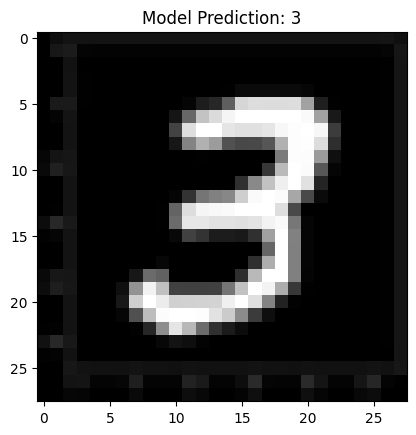

In [4]:
import torch
import PIL.ImageOps
from PIL import Image
import matplotlib.pyplot as plt

def test_my_image(image_path):
    # 1. Load the image and convert to Grayscale ('L')
    img = Image.open(image_path).convert('L')

    # 2. Resize to 28x28 (MNIST standard)
    img = img.resize((28, 28))

    # 3. Invert colors (MNIST is white ink on black background)
    # If your drawing is black ink on white paper, we MUST invert it.
    img = PIL.ImageOps.invert(img)

    # 4. Transform to Tensor and Normalize
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img_tensor = transform(img).unsqueeze(0) # Add a 'batch' dimension

    # 5. Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prediction = torch.argmax(output, dim=1).item()

    # 6. Show the result
    plt.imshow(img, cmap='gray')
    plt.title(f"Model Prediction: {prediction}")
    plt.show()

# Run the function
test_my_image('digit1.png')